<a href="https://colab.research.google.com/github/DanialNayyar/Mathematical-Modelling-Mini-Projects/blob/main/mathematical_methods/chapter1_preliminary_algebra/drone_position_and_los_calculator_2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORTS**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

**Distance formula**

$$ R = \sqrt{x^2 + y^2} $$

In [2]:
def distance(x,y):
  dist = math.sqrt(x**2 + y**2)
  return dist

In [3]:
R = distance(3,4)
print(R)

5.0


**theta**

$$θ = \tan^{-1}(\frac{y}{x}) $$


In [4]:
def theta(coords):

  x = coords[0]
  y = coords[1]

  angle = math.atan2(y,x)

  rads_to_degrees = 180 / math.pi
  angle = angle * rads_to_degrees


  return angle



**number of drones**

In [5]:
def num_drones(number_of_drones):
  # return list of tuples, each tuple is a drone pos
  list_of_drone_pos = []
  set_of_drone_pos = set()
  for i in range(0, number_of_drones):
    x_n = np.random.uniform(-1,1)
    y_n = np.random.uniform(-1,1)
    pos = (x_n,y_n)
    pos = round(pos[0],2), round(pos[1],2)
    if pos in set_of_drone_pos:
      continue
    else:
      set_of_drone_pos.add(pos)
      list_of_drone_pos.append(pos)

  return list_of_drone_pos


**Plot**

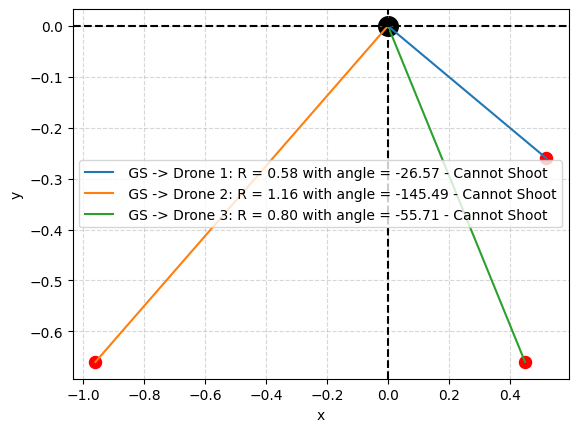

In [6]:
def plot(number_of_drones):
  number_of_drones = num_drones(number_of_drones)
  x_drone = []
  y_drone = []
  for i in number_of_drones:
    x_drone.append(i[0])
    y_drone.append(i[1])

  r_n = []
  for i in number_of_drones:
    r_n.append(distance(i[0],i[1]))

  theta_n = []
  for i in number_of_drones:
    theta_n.append(theta(i))



  x_gs, y_gs =0,0


  plt.scatter(x_gs,y_gs, color = "black", s = 200)
  plt.scatter(x_drone,y_drone, color = "red", s = 75)

  for drone_num, (x,y,r, angle) in enumerate(zip(x_drone, y_drone, r_n, theta_n), start = 1):



    if angle < 0:
      plt.plot([x_gs,x],[y_gs,y], label = f" GS -> Drone {drone_num}: R = {r:.2f} with angle = {angle:.2f} - Cannot Shoot")

    else:
      plt.plot([x_gs,x],[y_gs,y], label = f" GS -> Drone {drone_num}: R = {r:.2f} with angle = {angle:.2f} - TARGET DOWN")


  plt.axhline(y = 0, color = "black", linestyle = "--")
  plt.axvline(x = 0, color = "black", linestyle = "--")
  plt.xlabel("x")
  plt.ylabel("y")

  plt.grid(True, linestyle = "--", alpha = 0.5)

  plt.legend(loc = "best")
  plt.show()


plot(number_of_drones = 3)